<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F02_vertex_and_gce_vms.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 02 · Serverless Single-VM & Multi-Worker Jobs (`gce` & `vertex` Runtimes)

For workloads that do not require an Apache Spark or Ray cluster coordinator, `scale-forecasting` provides two direct container execution engines in `engines/vertex_engine.py`:
1. **GCE Ephemeral Single-VM (`runtime = 'gce'`):** Boots a single Container-Optimized OS (COS) VM with local `ProcessPoolExecutor` multiprocessing and **triple-redundant zero-orphan cleanup** (`maxRunDuration` + `instanceTerminationAction='DELETE'`, guest `trap cleanup EXIT` self-delete, and launcher `try...finally` deletion).
2. **Vertex AI CustomJob (`runtime = 'vertex'`):** Launches 1 to $N$ serverless worker replicas (`workerPoolSpecs`). When `workers > 1`, each replica pushes its contiguous `[start_id, end_id]` boundary directly into the **BigQuery Storage Read API** (`row_restriction`) and schedules chunks longest-first (**Longest Processing Time / LPT**).

```mermaid
flowchart LR
    subgraph Router["dag.py · resources/sizing.py"]
        CFG["RunConfig<br/>python_runtime = vertex or gce"] --> SZ["Auto-Sizing Catalog<br/>n2-standard-* · g2-standard-* (L4)<br/>a2-highgpu-* (A100)"]
    end
    subgraph Vertex["Vertex AI CustomJob (workers >= 1)"]
        W0["Worker 0 (CHIEF)<br/>BQ Read row_restriction [id_0..id_k]"]
        W1["Worker 1..N-1<br/>BQ Read row_restriction [id_k+1..id_M]"]
    end
    subgraph GCE["GCE Single-VM (workers == 1)"]
        VM["COS VM + ProcessPoolExecutor<br/>Triple-Redundant Auto-Delete"]
    end
    SZ --> W0 & W1 & VM --> BQ["BigQuery Storage Write API<br/>forecast_metadata · forecast_predictions"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Compare `gce` Single-VM vs. `vertex` Multi-Worker Plans with `explain()`

Before launching our live run, let's use `Forecaster.explain(validate_data=False)` to compare how the resource catalog (`resources/catalog.py` & `resources/sizing.py`) sizes:
- A **GCE Single-VM** run (`python_runtime='gce'`)
- A **Vertex AI CustomJob** run mixing CPU families (`statistical`, `ml`) with a GPU `deep_learning` family (`hardware='gpu'`, `gpu_type='L4'`)

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

gce_preview = RunConfig(
    run_name="preview-gce-single-vm",
    python_runtime="gce",
    data={"source_table": "source_series_iceberg", "horizon": 28, "series_limit": 200},
    models=["theta", "holtwinters", "lightgbm"],
    compute={"machine_type": "n2-standard-8", "workers": 1},
)
print("--- GCE Single-VM Plan ---")
display(Forecaster(gce_preview, settings=settings).explain(validate_data=False))

vertex_gpu_preview = RunConfig(
    run_name="preview-vertex-multi-family",
    python_runtime="vertex",
    data={"source_table": "source_series_iceberg", "horizon": 28, "series_limit": 200},
    models=["theta", "xgboost", "tide", "tsmixer"],
    compute={
        "machine_type": "n2-standard-8",
        "workers": 2,
        "families": {
            "deep_learning": {
                "runtime": "vertex",
                "hardware": "gpu",
                "gpu_type": "L4",
                "accelerator_count": 1,
                "workers": 2,
            }
        },
    },
)
print("--- Vertex AI Multi-Worker CPU + L4 GPU Plan ---")
display(Forecaster(vertex_gpu_preview, settings=settings).explain(validate_data=False))

--- GCE Single-VM Plan ---


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,preview-gce-single-vm-5cc5a953ef14,statistical,sf-preview-gce-single-vm-5cc5a953ef14-statisti...,gce,n2-standard-8,1,cpu,None,"theta, holtwinters","theta:local, holtwinters:local",200,1,400,none,
1,preview-gce-single-vm-5cc5a953ef14,ml,sf-preview-gce-single-vm-5cc5a953ef14-ml-a1,gce,n2-standard-8,1,cpu,None,lightgbm,lightgbm:local,200,1,200,none,


--- Vertex AI Multi-Worker CPU + L4 GPU Plan ---


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,preview-vertex-multi-family-c2c9611e2a47,statistical,sf-preview-vertex-multi-family-c2c9611e2a47-st...,vertex,n2-standard-8,2,cpu,None,theta,theta:local,200,1,200,none,
1,preview-vertex-multi-family-c2c9611e2a47,ml,sf-preview-vertex-multi-family-c2c9611e2a47-ml-a1,vertex,n2-standard-8,2,cpu,None,xgboost,xgboost:local,200,1,200,none,
2,preview-vertex-multi-family-c2c9611e2a47,deep_learning,sf-preview-vertex-multi-family-c2c9611e2a47-de...,vertex,g2-standard-8,2,gpu,L4,"tide, tsmixer","tide:local, tsmixer:local",200,1,400,none,


## Act 3 · Configure, Launch & Monitor a Live Vertex / GCE Run

Now let's configure and run a fast multi-family workload using `python_runtime='vertex'` (or switch `RUNTIME = 'gce'` to test ephemeral GCE VM execution) with `statistical` + `ml` models and in-run ensembling.

run_id: nb02-vertex-gce-1791144910-cb65652cf038


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb02-vertex-gce-1791144910-cb65652cf038,statistical,sf-nb02-vertex-gce-1791144910-cb65652cf038-sta...,vertex,n2-standard-8,1,cpu,None,"theta, naive_seasonal","theta:local, naive_seasonal:local",15,2,30,none,
1,nb02-vertex-gce-1791144910-cb65652cf038,ml,sf-nb02-vertex-gce-1791144910-cb65652cf038-ml-a1,vertex,n2-standard-8,1,cpu,None,lightgbm,lightgbm:local,15,2,15,none,
2,nb02-vertex-gce-1791144910-cb65652cf038,ensemble,sf-nb02-vertex-gce-1791144910-cb65652cf038-ens...,bigquery,sql,1,sql,None,"ensemble_mean, ensemble_inverse_error",barrier,15,2,30,none,sf-nb02-vertex-gce-1791144910-cb65652cf038-sta...


Completed nb02-vertex-gce-1791144910-cb65652cf038: status=COMPLETED, runtime=895.5s


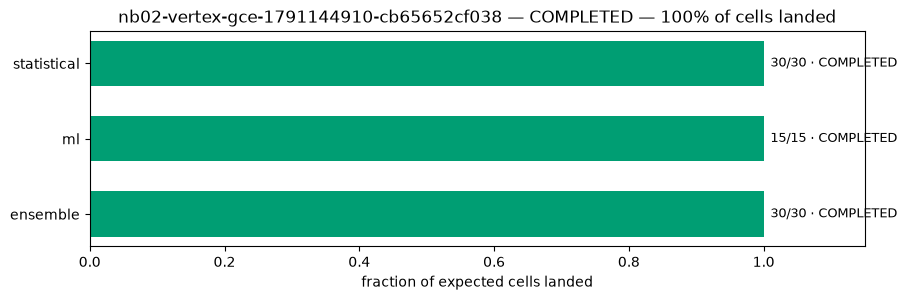

In [4]:
# === Parameters — edit me ===============================================
RUN_NAME = f"nb02 vertex gce {int(time.time())}"
RUNTIME = "vertex"  # "vertex" (Vertex AI CustomJob) or "gce" (Ephemeral Single-VM)
SOURCE_TABLE = "source_series_iceberg"
MODELS = ["theta", "naive_seasonal", "lightgbm"]
HORIZON = 28
SERIES_LIMIT = 15
N_FOLDS = 2
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime=RUNTIME,
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ["mean", "inverse_error"]},
)

forecaster = Forecaster(cfg, settings=settings)
print("run_id:", forecaster.run_id)
display(forecaster.explain())

result = forecaster.run_live(poll_s=15.0, probe=True)
print(f"Completed {result.run_id}: status={result.status}, runtime={result.runtime_seconds:.1f}s")

## Act 4 · Review Leaderboard, Forecast Intervals, Job Sizing & Cohort Health

Every Vertex AI CustomJob and GCE Single-VM family job records both its planned sizing (`$.sizing`) and actual executed hardware (`$.sizing_executed`) in `run_jobs.details` (`forecaster.jobs_df()`), and exposes backtest cohort coverage via `forecaster.cohorts_df()` (`v_backtest_coverage` + `v_model_leaderboard_comparable`).

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,ensemble_inverse_error,ensemble,True,55cf2eed0555,ensemble,15,wape,0.426720,0.137570,...,13.097401,17.180223,NaN,NaN,NaN,NaN,1.0,420,0.015121,0.034222
1,2,lightgbm,ml,False,None,vertex,15,wape,0.441840,0.151010,...,13.821479,18.199157,0.282143,99.018758,2.144549,1.236899,1.0,420,NaN,NaN
2,3,theta,statistical,False,None,vertex,15,wape,0.443389,0.158292,...,14.614160,18.970049,0.995238,262.555232,5.441080,4.326067,1.0,420,NaN,NaN
3,4,ensemble_mean,ensemble,True,55cf2eed0555,ensemble,15,wape,0.445685,0.147642,...,14.492586,19.324221,NaN,NaN,NaN,NaN,1.0,420,-0.003845,-0.008702
4,5,naive_seasonal,statistical,False,None,vertex,15,wape,0.562872,0.195826,...,19.792555,28.264536,0.694048,108.083731,0.979709,0.935429,1.0,420,NaN,NaN


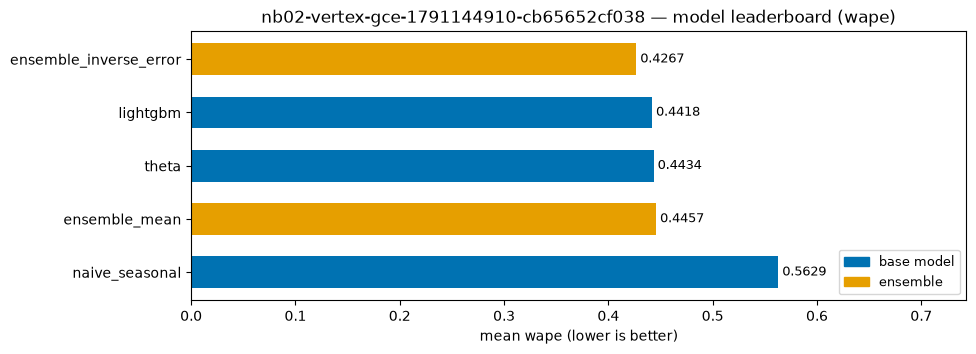

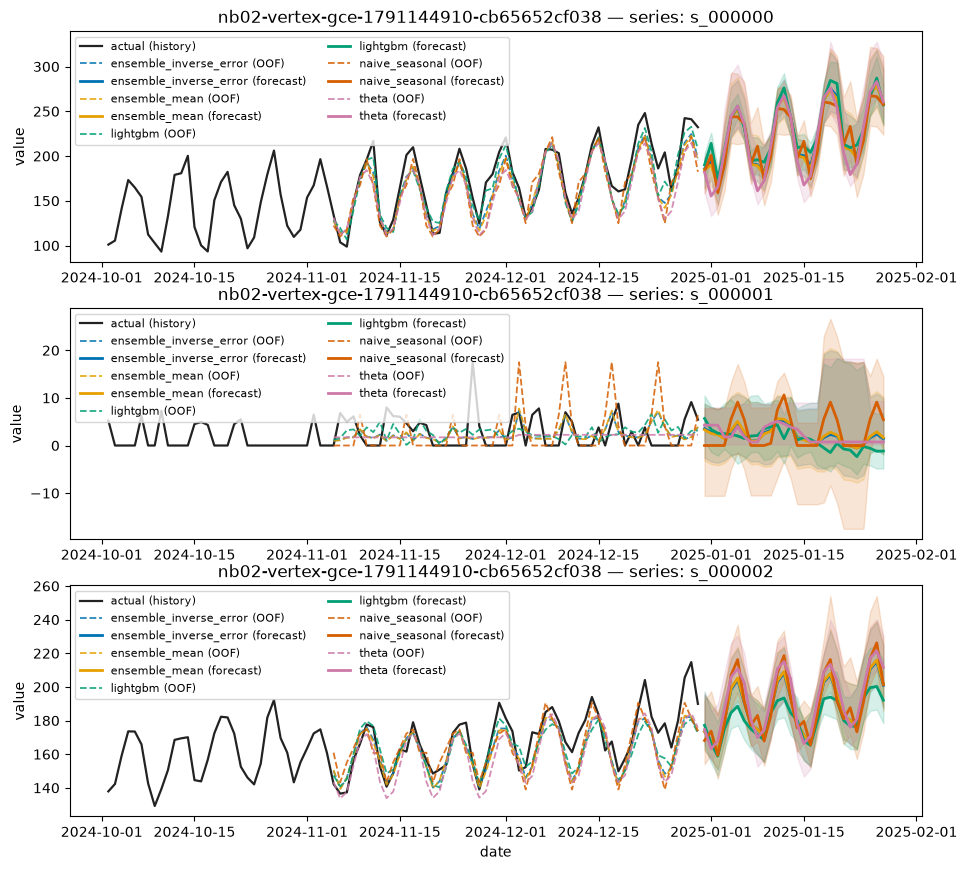

,kind,lane,label,start,end,duration_s,status,runtime,model_type,ts_id
0,job,ensemble,ensemble,2026-10-04 20:29:39.745418+00:00,2026-10-04 20:29:54.955569+00:00,15.210151,COMPLETED,bigquery,None,None
1,job,ml,ml,2026-10-04 20:15:54.533172+00:00,2026-10-04 20:29:34.264368+00:00,819.731196,COMPLETED,vertex,None,None
2,job,statistical,statistical,2026-10-04 20:15:54.623576+00:00,2026-10-04 20:29:01.869205+00:00,787.245629,COMPLETED,vertex,None,None
3,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,theta:s_000014,2026-10-04 20:27:19.524919+00:00,2026-10-04 20:27:37.105754+00:00,17.580835,None,vertex,theta,s_000014
4,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,theta:s_000003,2026-10-04 20:27:19.526030+00:00,2026-10-04 20:27:37.647792+00:00,18.121762,None,vertex,theta,s_000003
5,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,theta:s_000013,2026-10-04 20:27:19.527747+00:00,2026-10-04 20:27:37.035675+00:00,17.507928,None,vertex,theta,s_000013
6,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,theta:s_000004,2026-10-04 20:27:19.528364+00:00,2026-10-04 20:27:37.114101+00:00,17.585737,None,vertex,theta,s_000004
7,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,naive_seasonal:s_000013,2026-10-04 20:27:37.036370+00:00,2026-10-04 20:27:37.570747+00:00,0.534377,None,vertex,naive_seasonal,s_000013
8,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,naive_seasonal:s_000014,2026-10-04 20:27:37.106252+00:00,2026-10-04 20:27:37.894500+00:00,0.788248,None,vertex,naive_seasonal,s_000014
9,cell,cmle-training-workerpool0-75bdf581d1-0-gr584:1,naive_seasonal:s_000004,2026-10-04 20:27:37.114632+00:00,2026-10-04 20:27:37.784876+00:00,0.670244,None,vertex,naive_seasonal,s_000004


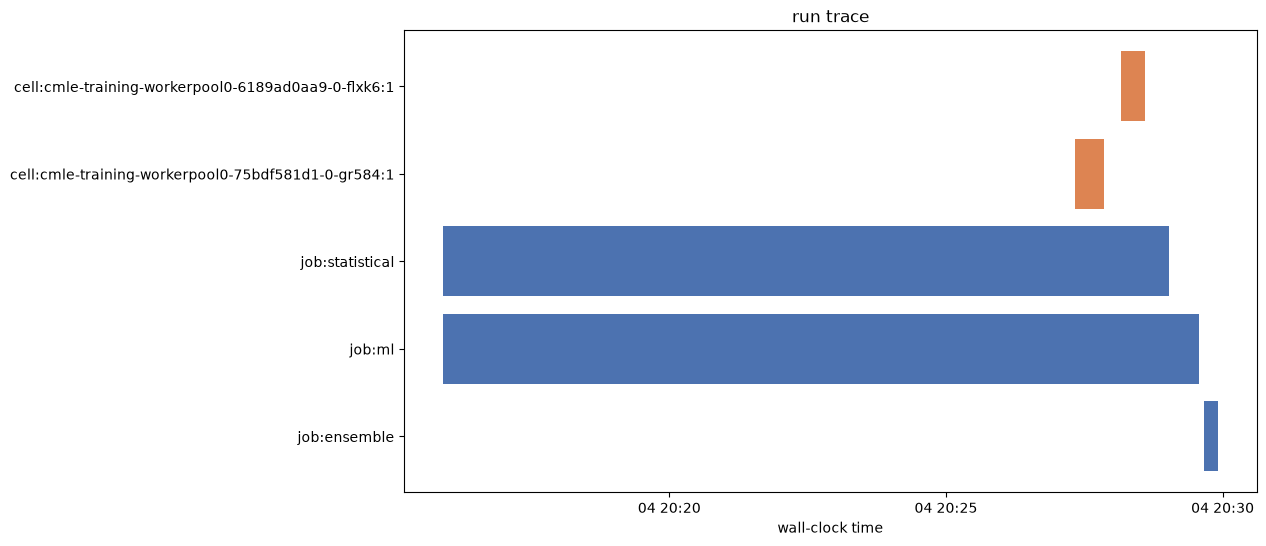

--- Per-Family Job Sizing & Telemetry (forecaster.jobs_df) ---


,family,job_key,system_job_id,runtime,status,attempt,hardware,gpu_type,spark_mode,runtime_seconds
0,ensemble,sf-nb02-vertex-gce-1791144910-cb65652cf038-ens...,sf-nb02-vertex-gce-1791144910-cb65652cf038-ens...,bigquery,COMPLETED,1,None,None,None,12.630997
1,ml,sf-nb02-vertex-gce-1791144910-cb65652cf038-ml-a1,projects/307701787156/locations/us-central1/cu...,vertex,COMPLETED,1,cpu,None,None,814.904786
2,statistical,sf-nb02-vertex-gce-1791144910-cb65652cf038-sta...,projects/307701787156/locations/us-central1/cu...,vertex,COMPLETED,1,cpu,None,None,782.116981


--- Backtest Cohort Health & Comparable Holdout Leaderboard (forecaster.cohorts_df) ---


,model_type,family,is_ensemble,n_series,score,pooled_wape,n_comparable_series,n_full,n_reduced,n_unscored,n_failed,n_not_requested,fold_histogram,refit_modes,staleness_gap
0,ensemble_inverse_error,ensemble,True,15,0.426720,0.137570,15,0,0,0,0,15,none,per_fold:15,None
1,lightgbm,ml,False,15,0.441840,0.151010,15,15,0,0,0,0,2f:15,per_fold:15,None
2,theta,statistical,False,15,0.443389,0.158292,15,15,0,0,0,0,2f:15,per_fold:15,None
3,ensemble_mean,ensemble,True,15,0.445685,0.147642,15,0,0,0,0,15,none,per_fold:15,None
4,naive_seasonal,statistical,False,15,0.562872,0.195826,15,15,0,0,0,0,2f:15,per_fold:15,None


In [5]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard, plot_trace

display(forecaster.leaderboard_df())

review = forecaster.review_run()
plot_leaderboard(review)
plt.show()

forecaster.plot_forecasts(history_tail=90)
plt.show()

trace_df = forecaster.trace()
display(trace_df)
plot_trace(trace_df)
plt.show()

print("--- Per-Family Job Sizing & Telemetry (forecaster.jobs_df) ---")
display(forecaster.jobs_df())

print("--- Backtest Cohort Health & Comparable Holdout Leaderboard (forecaster.cohorts_df) ---")
display(forecaster.cohorts_df())